In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv("data/initial_extended_frame.csv")
municipality_results = pd.read_csv("data/election_results.csv")
skeleton = pd.read_csv("data/sweden_strat_frame.csv")

# ------------------------------------------------------------
# OPTIONAL PARTY RECODING
# ------------------------------------------------------------
# other_left = {
#     "Ø: Enhedslisten",
#     "Å: Alternativet",
#     "B: Det Radikale Venstre",
# }
# other_right = {
#     "C: Det Konservative Folkeparti",
#     "D: Nye Borgerlige",
#     "O: Dansk Folkeparti",
# }
# other = {
#     "Independent candidate",
#     "Another party",
#     "Voted blank",
# }

# def recode_party(party: str) -> str:
#     if party in other_left:
#         return "Other - Left"
#     elif party in other_right:
#         return "Other - Right"
#     elif party in other:
#         return "Other"
#     return party

# ------------------------------------------------------------
# CLEAN TYPES
# ------------------------------------------------------------
df["municipality"] = df["municipality"].astype(str)
df["gender"] = df["gender"].astype(str)
df["age_group"] = df["age_group"].astype(str)
df["education_level"] = df["education_level"].astype(str)
df["past_vote"] = df["past_vote"].astype(str)
if "party" not in df.columns and "past_vote" in df.columns:
    df["party"] = df["past_vote"]
df["party"] = df["party"].astype(str)
df["expected_N"] = df["expected_N"].astype(float)

if "year" in municipality_results.columns:
    municipality_results = municipality_results.loc[
        municipality_results["year"] == 2022
    ].copy()
else:
    municipality_results = municipality_results.copy()

if "pop_pct" not in municipality_results.columns and "vote_pct" in municipality_results.columns:
    municipality_results = municipality_results.rename(columns={"vote_pct": "pop_pct"})

municipality_results["municipality"] = municipality_results["municipality"].astype(str)
party_series = municipality_results["party"].astype(str)
# Only apply optional recoding if helper is defined and enabled above.
if "recode_party" in globals():
    party_series = party_series.map(recode_party)
municipality_results["party"] = party_series
municipality_results["pop_pct"] = municipality_results["pop_pct"].astype(float)

skeleton["municipality"] = skeleton["municipality"].astype(str)
skeleton["gender"] = skeleton["gender"].astype(str)
skeleton["age_group"] = skeleton["age_group"].astype(str)

# skeleton may have "education" instead of "education_level"
if "education" in skeleton.columns and "education_level" not in skeleton.columns:
    skeleton = skeleton.rename(columns={"education": "education_level"})

skeleton["education_level"] = skeleton["education_level"].astype(str)

# ------------------------------------------------------------
# COLLAPSE ELECTION RESULTS TO MUNICIPALITY x PARTY
# ------------------------------------------------------------
municipality_results = (
    municipality_results
    .groupby(["municipality", "party"], as_index=False)["pop_pct"]
    .sum()
)

# Normalize within municipality just in case
municipality_results["pop_pct"] = (
    municipality_results["pop_pct"] /
    municipality_results.groupby("municipality")["pop_pct"].transform("sum")
)

# ------------------------------------------------------------
# BUILD SKELETON JOINT TARGETS
# ------------------------------------------------------------
cell_target_cols = ["municipality", "gender", "age_group", "education_level"]

skeleton_targets = (
    skeleton.groupby(cell_target_cols, as_index=False)["N"]
    .sum()
    .rename(columns={"N": "cell_target"})
)

# ------------------------------------------------------------
# BUILD MUNICIPALITY TOTALS FROM SKELETON
# ------------------------------------------------------------
municipality_totals = (
    skeleton_targets.groupby("municipality", as_index=False)["cell_target"]
    .sum()
    .rename(columns={"cell_target": "municipality_total_N"})
)

# ------------------------------------------------------------
# BUILD MUNICIPALITY x PARTY TARGET COUNTS
# ------------------------------------------------------------
mp_targets = (
    municipality_results
    .merge(municipality_totals, on="municipality", how="inner")
    .assign(target=lambda x: x["pop_pct"] * x["municipality_total_N"])
    .loc[:, ["municipality", "party", "target"]]
)

# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------
print("Initial total expected_N:", df["expected_N"].sum())
print("Total municipality-party target:", mp_targets["target"].sum())
print("Total skeleton target:", skeleton_targets["cell_target"].sum())

# These should all be very close
# If not, something is inconsistent in the inputs.

# ------------------------------------------------------------
# KEEP ONLY MATCHING SUPPORT
# ------------------------------------------------------------
# This avoids silent mismatches
mp_target_pairs = set(zip(mp_targets["municipality"], mp_targets["party"]))
df_pairs = set(zip(df["municipality"], df["party"]))

missing_mp_in_df = mp_target_pairs - df_pairs
missing_df_in_mp = df_pairs - mp_target_pairs

print("\nMunicipality-party pairs in targets not in df:", len(missing_mp_in_df))
print("Municipality-party pairs in df not in targets:", len(missing_df_in_mp))

# Cell support check
df_cell_keys = set(
    zip(df["municipality"], df["gender"], df["age_group"], df["education_level"])
)
target_cell_keys = set(
    zip(
        skeleton_targets["municipality"],
        skeleton_targets["gender"],
        skeleton_targets["age_group"],
        skeleton_targets["education_level"],
    )
)

missing_cells_in_df = target_cell_keys - df_cell_keys
missing_cells_in_targets = df_cell_keys - target_cell_keys

print("\nSkeleton cells in targets not in df:", len(missing_cells_in_df))
print("Cells in df not in skeleton targets:", len(missing_cells_in_targets))

# ------------------------------------------------------------
# IPF / RAKING TO BOTH MARGINS
# ------------------------------------------------------------
df_raked = df.copy()
df_raked["expected_N_raked"] = df_raked["expected_N"].astype(float)

max_iter = 200
tol = 1e-8
min_weight = 1e-12

for it in range(max_iter):
    # ---- Step 1: rake to municipality x party ----
    current_mp = (
        df_raked.groupby(["municipality", "party"], as_index=False)["expected_N_raked"]
        .sum()
        .rename(columns={"expected_N_raked": "current"})
    )

    adj_mp = (
        mp_targets.merge(current_mp, on=["municipality", "party"], how="left")
        .assign(current=lambda x: x["current"].fillna(0.0))
    )

    adj_mp["factor_mp"] = np.where(
        adj_mp["current"] > 0,
        adj_mp["target"] / adj_mp["current"],
        1.0,
    )

    df_raked = (
        df_raked.merge(
            adj_mp[["municipality", "party", "factor_mp"]],
            on=["municipality", "party"],
            how="left"
        )
        .assign(
            factor_mp=lambda x: x["factor_mp"].fillna(1.0),
            expected_N_raked=lambda x: np.maximum(
                x["expected_N_raked"] * x["factor_mp"],
                min_weight
            )
        )
        .drop(columns="factor_mp")
    )

    # ---- Step 2: rake to demographic joint cell margin ----
    current_cell = (
        df_raked.groupby(cell_target_cols, as_index=False)["expected_N_raked"]
        .sum()
        .rename(columns={"expected_N_raked": "current"})
    )

    adj_cell = (
        skeleton_targets.merge(current_cell, on=cell_target_cols, how="left")
        .assign(current=lambda x: x["current"].fillna(0.0))
    )

    adj_cell["factor_cell"] = np.where(
        adj_cell["current"] > 0,
        adj_cell["cell_target"] / adj_cell["current"],
        1.0,
    )

    df_raked = (
        df_raked.merge(
            adj_cell[cell_target_cols + ["factor_cell"]],
            on=cell_target_cols,
            how="left"
        )
        .assign(
            factor_cell=lambda x: x["factor_cell"].fillna(1.0),
            expected_N_raked=lambda x: np.maximum(
                x["expected_N_raked"] * x["factor_cell"],
                min_weight
            )
        )
        .drop(columns="factor_cell")
    )

    # ---- convergence check ----
    check_mp = (
        df_raked.groupby(["municipality", "party"])["expected_N_raked"]
        .sum()
        .reset_index()
        .merge(mp_targets, on=["municipality", "party"], how="left")
    )
    check_mp["abs_err"] = (check_mp["expected_N_raked"] - check_mp["target"]).abs()

    check_cell = (
        df_raked.groupby(cell_target_cols)["expected_N_raked"]
        .sum()
        .reset_index()
        .merge(skeleton_targets, on=cell_target_cols, how="left")
    )
    check_cell["abs_err"] = (check_cell["expected_N_raked"] - check_cell["cell_target"]).abs()

    max_err = max(check_mp["abs_err"].max(), check_cell["abs_err"].max())

    if it % 10 == 0 or max_err < tol:
        print(f"Iteration {it + 1}: max abs margin error = {max_err:.10f}")

    if max_err < tol:
        print("Converged.")
        break

# ------------------------------------------------------------
# RECOMPUTE PARTY PROBABILITIES WITHIN CELL
# ------------------------------------------------------------
cell_totals = df_raked.groupby("cell_id")["expected_N_raked"].transform("sum")

df_raked["prob_raked"] = np.where(
    cell_totals > 0,
    df_raked["expected_N_raked"] / cell_totals,
    np.nan
)

# ------------------------------------------------------------
# VALIDATION: BOTH MARGINS
# ------------------------------------------------------------
validation_mp = (
    df_raked.groupby(["municipality", "party"], as_index=False)["expected_N_raked"]
    .sum()
    .rename(columns={"expected_N_raked": "raked"})
    .merge(mp_targets, on=["municipality", "party"], how="left")
)

validation_mp["abs_error"] = (validation_mp["raked"] - validation_mp["target"]).abs()

validation_cell = (
    df_raked.groupby(cell_target_cols, as_index=False)["expected_N_raked"]
    .sum()
    .rename(columns={"expected_N_raked": "raked"})
    .merge(skeleton_targets, on=cell_target_cols, how="left")
)

validation_cell["abs_error"] = (validation_cell["raked"] - validation_cell["cell_target"]).abs()

print("\nMunicipality x party validation:")
print(validation_mp["abs_error"].describe())

print("\nDemographic joint-cell validation:")
print(validation_cell["abs_error"].describe())

# ------------------------------------------------------------
# NATIONAL PARTY SHARES AFTER RAKING
# ------------------------------------------------------------
national_party = (
    df_raked.groupby("party", as_index=False)["expected_N_raked"]
    .sum()
    .rename(columns={"expected_N_raked": "expected_total_raked"})
)

national_total = national_party["expected_total_raked"].sum()
national_party["share_raked"] = national_party["expected_total_raked"] / national_total

print("\nNational party shares after raking:")
print(national_party.sort_values("share_raked", ascending=False))

# ------------------------------------------------------------
# SAVE OUTPUTS
# ------------------------------------------------------------
candidate_output_dirs = [Path("mrp_outputs"), Path("../mrp_outputs")]
output_dir = next((p for p in candidate_output_dirs if p.exists()), Path("mrp_outputs"))
output_dir.mkdir(parents=True, exist_ok=True)

df_raked.to_csv(output_dir / "mrp_extended_frame_raked.csv", index=False)
validation_mp.to_csv(output_dir / "mrp_raking_validation_municipality_party.csv", index=False)
validation_cell.to_csv(output_dir / "mrp_raking_validation_demographic_cells.csv", index=False)
national_party.to_csv(output_dir / "mrp_national_party_shares_raked_both_margins.csv", index=False)

print("\nSaved:")
print(f"- {output_dir / 'mrp_extended_frame_raked.csv'}")
print(f"- {output_dir / 'mrp_raking_validation_municipality_party.csv'}")
print(f"- {output_dir / 'mrp_raking_validation_demographic_cells.csv'}")
print(f"- {output_dir / 'mrp_national_party_shares_raked_both_margins.csv'}")

Initial total expected_N: 7903796.500000001
Total municipality-party target: 7903796.5
Total skeleton target: 7903796.5

Municipality-party pairs in targets not in df: 130
Municipality-party pairs in df not in targets: 10

Skeleton cells in targets not in df: 1016
Cells in df not in skeleton targets: 82
Iteration 1: max abs margin error = 6528.0088804779
Iteration 11: max abs margin error = 0.0030166929
Iteration 21: max abs margin error = 0.0000000329
Iteration 23: max abs margin error = 0.0000000033
Converged.

Municipality x party validation:
count    2.730000e+03
mean     5.172645e-12
std      9.489495e-11
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.136868e-13
max      3.347964e-09
Name: abs_error, dtype: float64

Demographic joint-cell validation:
count    2.196500e+04
mean     9.715414e-15
std      6.028414e-14
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.637979e-12
Name: abs_error, dtype: floa

Using raked frame: ../mrp_outputs/sweden_frame_raked.csv
Using election results: data/election_results.csv
Using quartiles: ../mrp_outputs/mrp_municipality_party_quartiles.csv
=== Overall Metrics ===
Rows matched : 2770
IQR Coverage : 0.0%
Spearman r   : 1.000  (p = nan)
Bias         : +0.000 pp
RMSE         : 0.270 pp


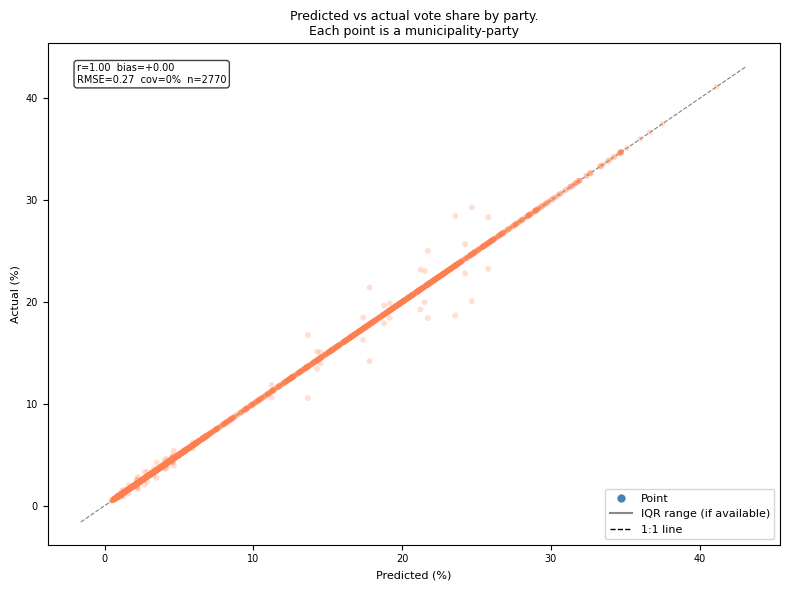

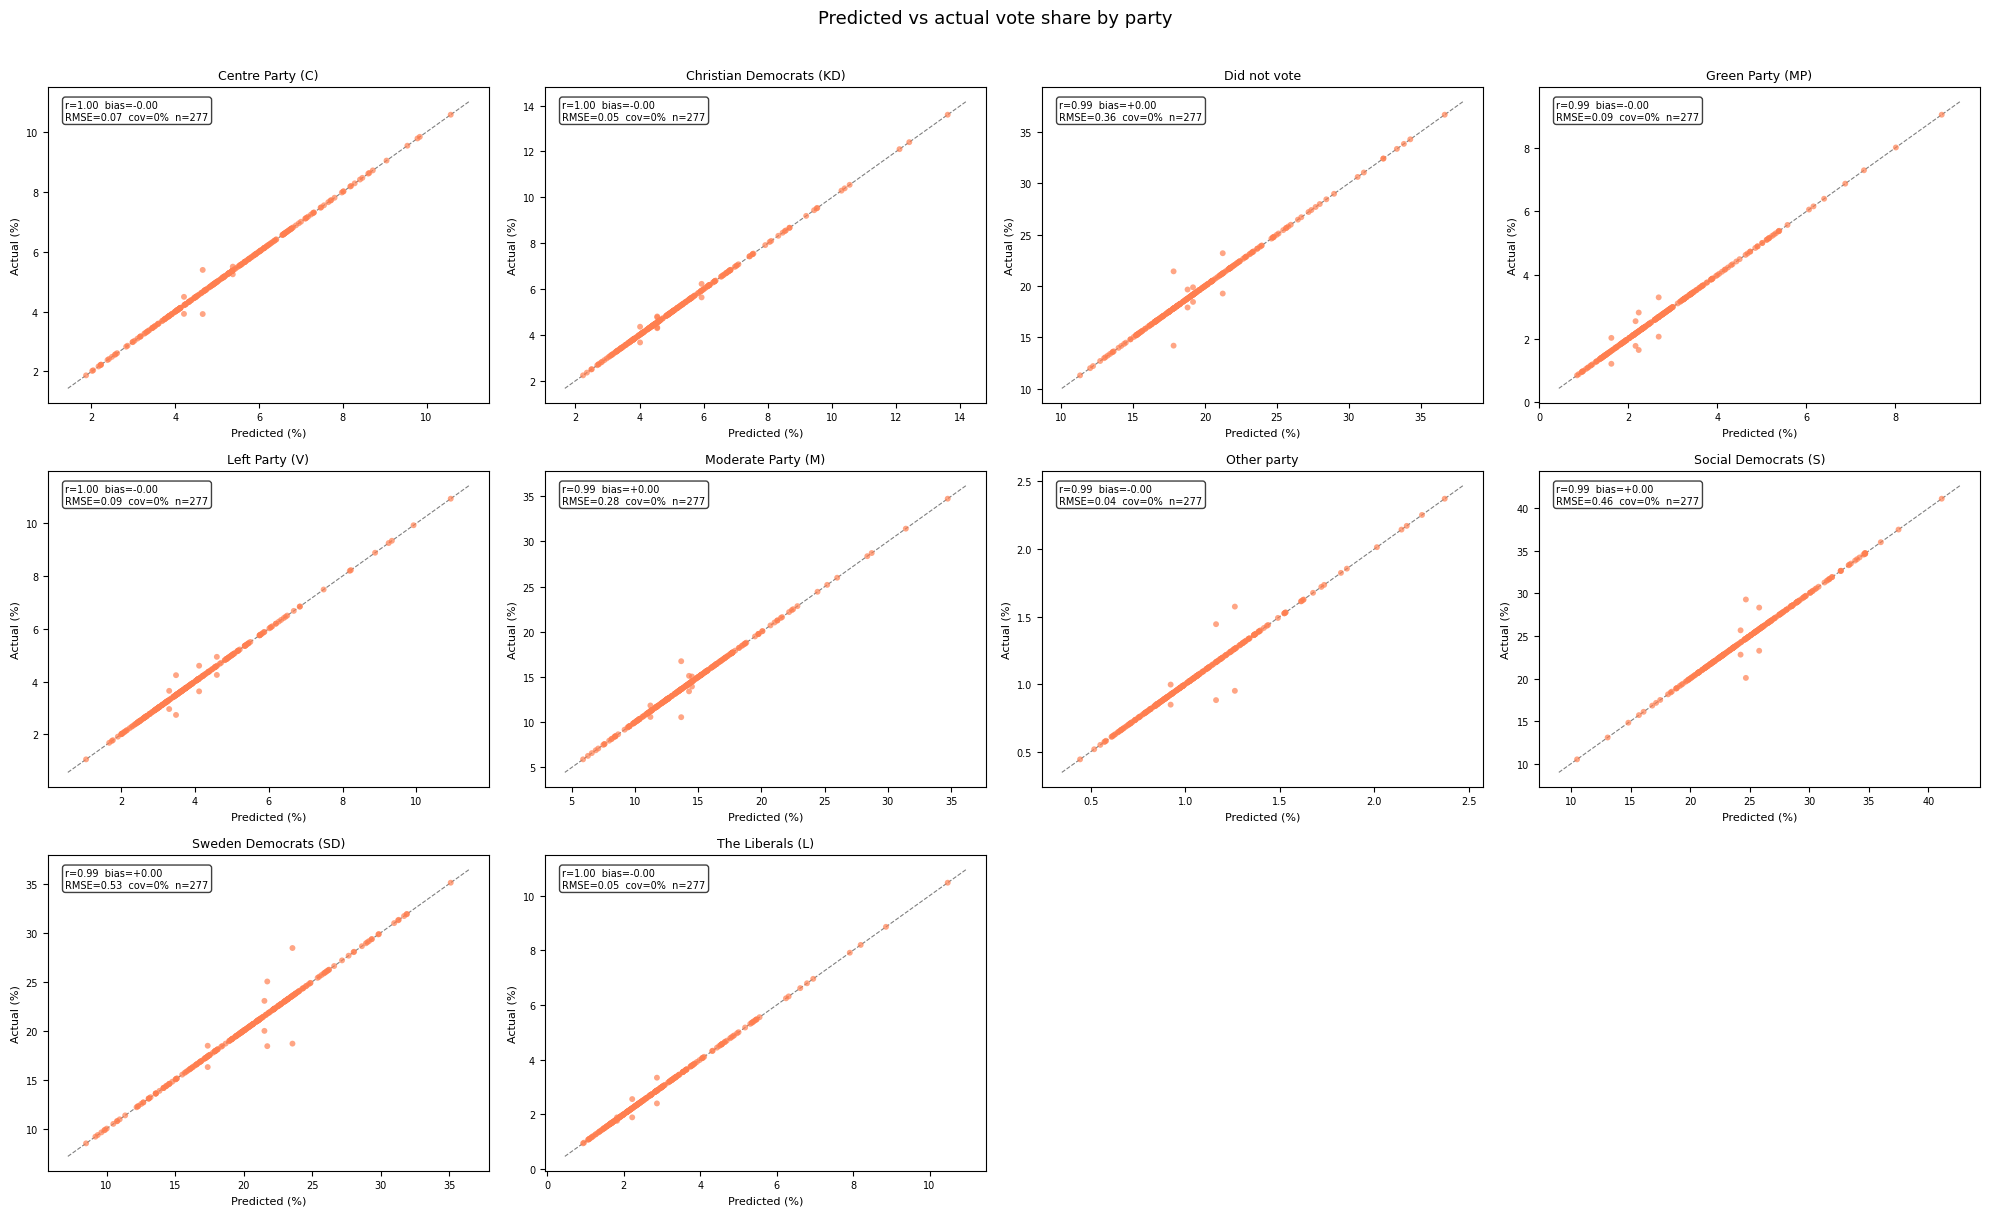

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import warnings
from matplotlib.lines import Line2D

# Fallback if this cell is run without executing the first setup cell
try:
    stats
except NameError:
    class _StatsFallback:
        @staticmethod
        def spearmanr(a, b):
            a_series = pd.Series(a)
            b_series = pd.Series(b)
            valid = ~(a_series.isna() | b_series.isna())
            if valid.sum() < 2:
                return np.nan, np.nan
            corr = a_series[valid].corr(b_series[valid], method="spearman")
            return float(corr), np.nan

    stats = _StatsFallback()
    print("Info: using pandas-based Spearman fallback (p-values set to NaN).")


def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None


# ------------------------------------------------------------
# PATH DISCOVERY (works whether cwd is sweden_data/ or repo root)
# ------------------------------------------------------------
frame_path = first_existing([
    Path("mrp_outputs/sweden_frame_raked.csv"),
    Path("../mrp_outputs/sweden_frame_raked.csv"),
    Path("mrp_outputs/mrp_extended_frame_raked.csv"),
    Path("../mrp_outputs/mrp_extended_frame_raked.csv"),
])
if frame_path is None:
    raise FileNotFoundError("Could not find a raked frame CSV under mrp_outputs/.")

quartiles_path = first_existing([
    Path("mrp_outputs/mrp_municipality_party_quartiles.csv"),
    Path("../mrp_outputs/mrp_municipality_party_quartiles.csv"),
])

actual_path = first_existing([
    Path("data/election_results.csv"),
    Path("sweden_data/data/election_results.csv"),
])
if actual_path is None:
    raise FileNotFoundError("Could not find data/election_results.csv.")

print(f"Using raked frame: {frame_path}")
print(f"Using election results: {actual_path}")
if quartiles_path is not None:
    print(f"Using quartiles: {quartiles_path}")
else:
    print("Info: quartiles file not found; coverage metrics will be skipped.")

# ------------------------------------------------------------
# LOAD AND BUILD MUNICIPALITY x PARTY PREDICTIONS
# ------------------------------------------------------------
df_frame = pd.read_csv(frame_path)

party_col_frame = "party" if "party" in df_frame.columns else "past_vote"
weight_col = "expected_N_raked" if "expected_N_raked" in df_frame.columns else "expected_N"

pred = (
    df_frame
    .assign(past_vote=df_frame[party_col_frame].astype(str))
    .groupby(["municipality", "past_vote"], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "predicted_total"})
)
pred["predicted"] = pred["predicted_total"] / pred.groupby("municipality")["predicted_total"].transform("sum")
pred = pred[["municipality", "past_vote", "predicted"]]

# ------------------------------------------------------------
# LOAD ACTUALS
# ------------------------------------------------------------
df_actual = pd.read_csv(actual_path)

actual_col = next(
    (c for c in ["pop_pct", "vote_pct", "actual", "share", "pct"] if c in df_actual.columns),
    None,
)
if actual_col is None:
    raise ValueError(
        "Could not find an actual-share column in election results. "
        f"Expected one of ['pop_pct', 'vote_pct', 'actual', 'share', 'pct']; found {list(df_actual.columns)}"
    )

municipality_col = next(
    (c for c in ["municipality", "kommun", "municipality_name"] if c in df_actual.columns),
    None,
)
if municipality_col is None:
    raise ValueError(
        "Could not find municipality column in election results. "
        f"Found columns: {list(df_actual.columns)}"
    )

if "past_vote" in df_actual.columns:
    party_series = df_actual["past_vote"].astype(str)
elif "party" in df_actual.columns:
    party_series = df_actual["party"].astype(str)
else:
    raise ValueError(
        "Could not find party label column in election results. "
        f"Expected 'party' or 'past_vote'; found {list(df_actual.columns)}"
    )

# Align naming with modeled party labels
party_series = party_series.str.replace("Non-voter", "Did not vote", regex=False)
pred["past_vote"] = pred["past_vote"].str.replace("Non-voter", "Did not vote", regex=False)

df_a = (
    df_actual
    .copy()
    .assign(past_vote=party_series)
    .rename(columns={municipality_col: "municipality", actual_col: "actual"})
    [["municipality", "past_vote", "actual"]]
)

# ------------------------------------------------------------
# OPTIONAL QUARTILES MERGE
# ------------------------------------------------------------
if quartiles_path is not None:
    df_q = pd.read_csv(quartiles_path)
    q_party_col = "past_vote" if "past_vote" in df_q.columns else "party"
    df_q = df_q.rename(columns={q_party_col: "past_vote"})
    df_q["past_vote"] = df_q["past_vote"].astype(str).str.replace("Non-voter", "Did not vote", regex=False)

    merged = (
        pred
        .merge(df_q[["municipality", "past_vote", "lower_quartile", "upper_quartile"]], on=["municipality", "past_vote"], how="left")
        .merge(df_a, on=["municipality", "past_vote"], how="inner")
        .assign(
            in_iqr=lambda d: (
                d["lower_quartile"].notna() &
                d["upper_quartile"].notna() &
                (d["actual"] >= d["lower_quartile"]) &
                (d["actual"] <= d["upper_quartile"])
            )
        )
    )
else:
    merged = pred.merge(df_a, on=["municipality", "past_vote"], how="inner")
    merged["lower_quartile"] = np.nan
    merged["upper_quartile"] = np.nan
    merged["in_iqr"] = np.nan

if merged.empty:
    raise ValueError(
        "No rows matched between raked predictions and election_results.csv. "
        "Check party naming and municipality strings."
    )

merged = merged.assign(
    pred_pct=lambda d: d["predicted"] * 100,
    actual_pct=lambda d: d["actual"] * 100,
    lo=lambda d: d["lower_quartile"] * 100,
    hi=lambda d: d["upper_quartile"] * 100,
)

# ------------------------------------------------------------
# OVERALL METRICS
# ------------------------------------------------------------
sp_r, sp_p = stats.spearmanr(merged["pred_pct"], merged["actual_pct"])
bias = (merged["pred_pct"] - merged["actual_pct"]).mean()
rmse = np.sqrt(((merged["pred_pct"] - merged["actual_pct"]) ** 2).mean())

print("=== Overall Metrics ===")
print(f"Rows matched : {len(merged)}")
if merged["in_iqr"].notna().any():
    coverage = merged.loc[merged["in_iqr"].notna(), "in_iqr"].mean() * 100
    print(f"IQR Coverage : {coverage:.1f}%")
else:
    print("IQR Coverage : n/a (quartiles unavailable)")
print(f"Spearman r   : {sp_r:.3f}  (p = {sp_p:.2e})")
print(f"Bias         : {bias:+.3f} pp")
print(f"RMSE         : {rmse:.3f} pp")


def plot_scatter(ax, sub, title, alpha_pts=0.5):
    has_iqr = sub["in_iqr"].notna().any()
    if has_iqr:
        colors = np.where(sub["in_iqr"], "steelblue", "coral")
    else:
        colors = "steelblue"

    if sub["lo"].notna().any() and sub["hi"].notna().any():
        iqr_sub = sub[sub["lo"].notna() & sub["hi"].notna()]
        ax.hlines(
            iqr_sub["actual_pct"],
            iqr_sub["lo"],
            iqr_sub["hi"],
            colors="#888888",
            linewidth=0.7,
            alpha=0.4,
            zorder=1,
        )

    ax.scatter(
        sub["pred_pct"],
        sub["actual_pct"],
        c=colors,
        s=18,
        alpha=alpha_pts,
        zorder=3,
        linewidths=0,
    )

    vmin = min(sub[["pred_pct", "actual_pct"]].min())
    vmax = max(sub[["pred_pct", "actual_pct"]].max())
    if sub["lo"].notna().any():
        vmin = min(vmin, sub["lo"].min())
    if sub["hi"].notna().any():
        vmax = max(vmax, sub["hi"].max())

    pad = (vmax - vmin) * 0.05 if vmax > vmin else 1
    ax.plot(
        [vmin - pad, vmax + pad],
        [vmin - pad, vmax + pad],
        "k--",
        linewidth=0.8,
        alpha=0.5,
        zorder=2,
    )

    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Predicted (%)", fontsize=8)
    ax.set_ylabel("Actual (%)", fontsize=8)
    ax.tick_params(labelsize=7)

    n = len(sub)
    if n >= 3:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r, _ = stats.spearmanr(sub["pred_pct"], sub["actual_pct"])

        r_str = f"{r:.2f}" if not np.isnan(r) else "n/a"
        b = (sub["pred_pct"] - sub["actual_pct"]).mean()
        rm = np.sqrt(((sub["pred_pct"] - sub["actual_pct"]) ** 2).mean())
        if has_iqr:
            cov = sub["in_iqr"].mean() * 100
            txt = f"r={r_str}  bias={b:+.2f}\nRMSE={rm:.2f}  cov={cov:.0f}%  n={n}"
        else:
            txt = f"r={r_str}  bias={b:+.2f}\nRMSE={rm:.2f}  n={n}"
    else:
        txt = f"n={n}"

    ax.text(
        0.04,
        0.96,
        txt,
        transform=ax.transAxes,
        fontsize=7,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.75),
    )


legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=7, label="Point"),
    Line2D([0], [0], color="#888888", linewidth=1.5, label="IQR range (if available)"),
    Line2D([0], [0], color="k", linestyle="--", linewidth=1, label="1:1 line"),
]

# Fig 1: All municipalities x parties
fig_all, ax_all = plt.subplots(figsize=(8, 6))
plot_scatter(
    ax_all,
    merged,
    "Predicted vs actual vote share by party.\nEach point is a municipality-party",
    alpha_pts=0.25,
)
ax_all.legend(handles=legend_elements, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# Fig 2: Per-party subplots
parties = sorted(merged["past_vote"].unique())
n_parties = len(parties)
n_cols = 4
n_rows = math.ceil(n_parties / n_cols)

fig_p, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes_flat = np.array(axes).reshape(-1)

for i, party in enumerate(parties):
    sub = merged[merged["past_vote"] == party].copy()
    plot_scatter(axes_flat[i], sub, party, alpha_pts=0.7)

for j in range(n_parties, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig_p.suptitle("Predicted vs actual vote share by party", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()